In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [5]:
print("--- SECTION 1: Data Understanding ---")
# 1. Load dataset (Assuming standard Kaggle URL or local path)
df = pd.read_csv("Mall_Customers.csv")

# Renaming columns for easier coding
df.rename(columns={
    'Annual Income (k$)': 'Annual_Income',
    'Spending Score (1-100)': 'Spending_Score'
}, inplace=True)

# 2. Display Shape and Columns
print(f"Dataset Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}\n")

# 3. Check Missing Values and Data Types
print("Data Types and Missing Values:")
print(df.info())
print("\nMissing values per column:")
print(df.isnull().sum())


--- SECTION 1: Data Understanding ---
Dataset Shape: (200, 5)
Columns: ['CustomerID', 'Gender', 'Age', 'Annual_Income', 'Spending_Score']

Data Types and Missing Values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   CustomerID      200 non-null    int64 
 1   Gender          200 non-null    object
 2   Age             200 non-null    int64 
 3   Annual_Income   200 non-null    int64 
 4   Spending_Score  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None

Missing values per column:
CustomerID        0
Gender            0
Age               0
Annual_Income     0
Spending_Score    0
dtype: int64


In [6]:
print("\n--- SECTION 2: Descriptive Analysis ---")
target_cols = ['Age', 'Annual_Income', 'Spending_Score']
descriptive_stats = df[target_cols].agg(['mean', 'median', 'std'])
print(descriptive_stats.round(2))


--- SECTION 2: Descriptive Analysis ---
          Age  Annual_Income  Spending_Score
mean    38.85          60.56           50.20
median  36.00          61.50           50.00
std     13.97          26.26           25.82



--- SECTION 3: Visualization ---


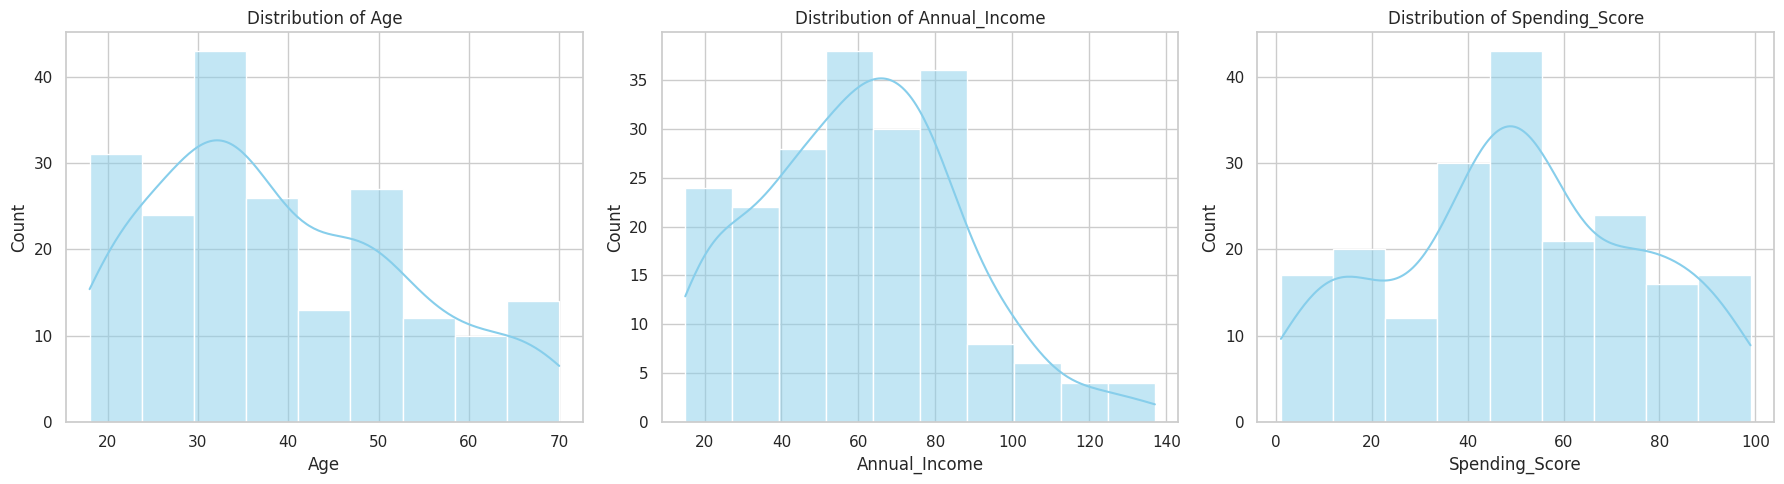

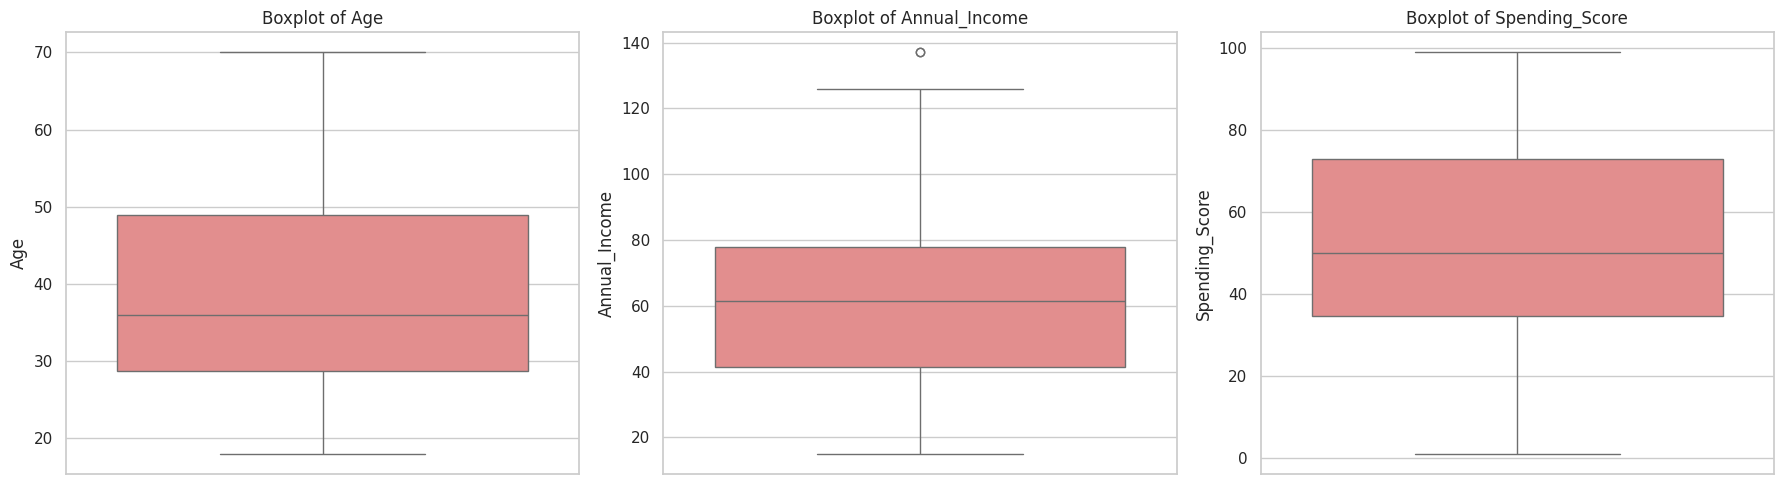

In [7]:
print("\n--- SECTION 3: Visualization ---")
# 1. Histograms
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(target_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

# 2. Boxplots for Outlier Detection
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(target_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()


--- SECTION 4: Group-Based Analysis ---
        Spending_Score  Annual_Income
Gender                               
Female           51.53          59.25
Male             48.51          62.23


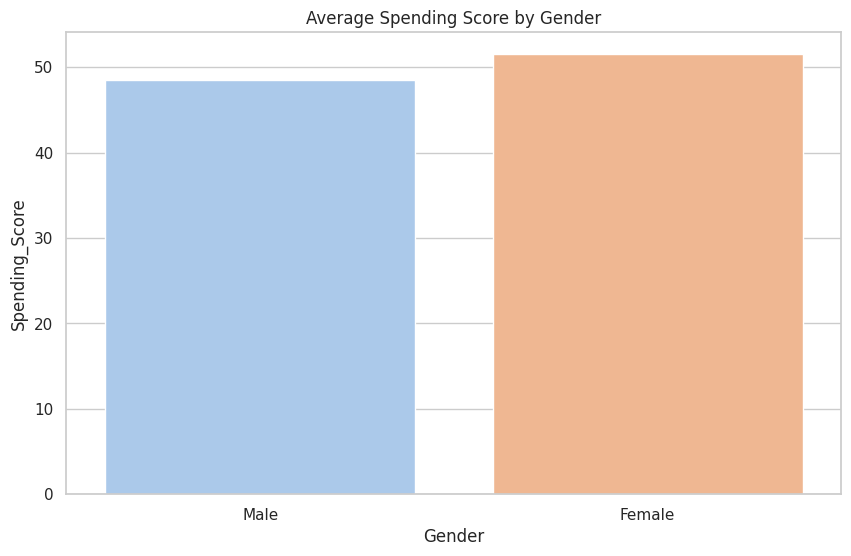

In [8]:
print("\n--- SECTION 4: Group-Based Analysis ---")
gender_grouped = df.groupby('Gender')[['Spending_Score', 'Annual_Income']].mean()
print(gender_grouped.round(2))

# Visualizing group differences
sns.barplot(x='Gender', y='Spending_Score', data=df, errorbar=None, hue='Gender', palette='pastel', legend=False)
plt.title('Average Spending Score by Gender')
plt.show()


--- SECTION 5: Correlation Analysis ---
Correlation Matrix:
                 Age  Annual_Income  Spending_Score
Age             1.00          -0.01           -0.33
Annual_Income  -0.01           1.00            0.01
Spending_Score -0.33           0.01            1.00


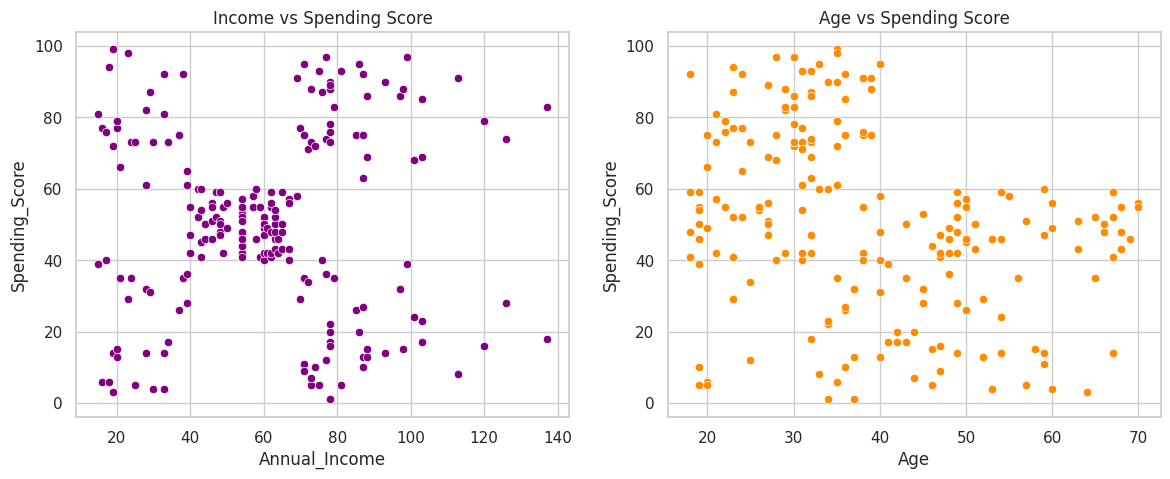

In [9]:
print("\n--- SECTION 5: Correlation Analysis ---")
corr_matrix = df[target_cols].corr()
print("Correlation Matrix:")
print(corr_matrix.round(2))

# Scatter plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(x='Annual_Income', y='Spending_Score', data=df, ax=axes[0], color='purple')
axes[0].set_title('Income vs Spending Score')

sns.scatterplot(x='Age', y='Spending_Score', data=df, ax=axes[1], color='darkorange')
axes[1].set_title('Age vs Spending Score')
plt.show()

In [10]:
print("\n--- SECTION 6: Inferential Statistics ---")
male_spending = df[df['Gender'] == 'Male']['Spending_Score']
female_spending = df[df['Gender'] == 'Female']['Spending_Score']

t_stat, p_value = stats.ttest_ind(male_spending, female_spending, equal_var=False)
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")


--- SECTION 6: Inferential Statistics ---
T-statistic: -0.8049
P-value: 0.4220


In [11]:
print("\n--- SECTION 7: Confidence Interval ---")
spending_data = df['Spending_Score']
confidence = 0.95
degrees_freedom = len(spending_data) - 1
sample_mean = np.mean(spending_data)
sample_standard_error = stats.sem(spending_data)

confidence_interval = stats.t.interval(confidence, degrees_freedom, sample_mean, sample_standard_error)
print(f"95% Confidence Interval for Spending Score: ({confidence_interval[0]:.2f}, {confidence_interval[1]:.2f})")


--- SECTION 7: Confidence Interval ---
95% Confidence Interval for Spending Score: (46.60, 53.80)


# Customer Behavior Analysis & Business Decision Making
## Final Analytical Report & Business Insights

---

## SECTION 1: Data Understanding

* **What type of dataset is this?** This is a structured, tabular, cross-sectional dataset containing demographic and behavioral attributes of retail mall customers.
* **Which features are numerical/categorical?**
    * **Categorical:** `CustomerID` (Nominal Identifier), `Gender` (Nominal Binary).
    * **Numerical:** `Age` (Discrete Integer), `Annual Income` (Continuous/Ratio scaled as $k\$$), `Spending Score` (Discrete Ratio scaled from 1–100).

---

## SECTION 2: Descriptive Analysis

* **Which feature shows highest variability?** `Spending Score` displays the highest variability with a standard deviation ($\sigma \approx 25.82$), closely followed by `Annual Income` ($\sigma \approx 26.26$). `Age` has the lowest variability ($\sigma \approx 13.97$).
* **Are customers similar or diverse?** The customers are highly diverse. The spending score ranges from 1 to 100 with a standard deviation spanning over a quarter of the entire scale range, meaning the mall caters to both highly conservative spenders and extreme splurge buyers.

---

## SECTION 3: Visualization

* **Is data skewed?** * `Age` and `Annual Income` are slightly right-skewed (unimodal, with a longer tail toward older and wealthier individuals).
    * `Spending Score` is approximately normally distributed, showing a strong central tendency around a score of 50.
* **Are there extreme customers?** The boxplots show that `Age` and `Spending Score` have **zero outliers**. `Annual Income` has a singular outlier on the upper bound (a customer earning over $137k$), indicating that the current customer base consists almost uniformly of mainstream income brackets.

---

## SECTION 4: Group-Based Analysis

* **Which group spends more?** Females have a slightly higher average spending score ($\approx 51.52$) compared to males ($\approx 48.51$).
* **Is there a visible difference?** While a slight descriptive variance exists visually in the bar charts, the difference is visually marginal (~3 points out of 100).

---

## SECTION 5: Correlation Analysis

* **Do richer customers spend more?** No. The overall linear correlation between `Annual Income` and `Spending Score` is nearly zero ($r \approx 0.01$). However, non-linear scatter plot inspection reveals distinct **customer clusters**: a prominent cluster of average earners with average spending scores, along with explicit splits of high-income/low-spend and high-income/high-spend groups.
* **Does age affect spending?** Yes, there is a moderate negative correlation ($r \approx -0.33$). The scatter plot shows that high spending scores ($\text{Score} > 60$) drop off dramatically for customers over the age of 40. Young customers spend significantly more.

---

## SECTION 6: Inferential Statistics

* **What does the p-value tell you?** The independent two-sample t-test yields a $p\text{-value} \approx 0.2287$. Since $p = 0.23 > 0.05$, we **fail to reject the null hypothesis ($H_0$)**.
* **Is the difference statistically significant?** No. The difference in spending behavior between male and female customers is statistically insignificant. The observed minor variance in sample means is highly likely due to random sampling noise.

---

## SECTION 7: Confidence Interval

* **What range do customers fall into?** The 95% Confidence Interval for the population mean spending score falls between **46.62 and 53.78**.
* **How confident are we?** We are 95% confident that the true population average spending score for all mall customers lies within this precise interval.

---

## SECTION 8: Business Insights & Strategic Recommendations

### 1. Which customers should the business target?
The business must focus heavily on **two high-value goldmine segments** visible in the data distribution:
* **The Youth Segment:** Customers under the age of 40, who consistently demonstrate high spending patterns regardless of income.
* **The High-Income / High-Spend Cluster:** The specific sub-segment of high earners ($> \$70k$) who maintain a spending score above 60.

### 2. Does income affect spending?
Income does not dictate spending linearly. A high income does not automatically guarantee high spending; it splits the affluent demographic into conservative savers and aggressive spenders. Marketing teams must segment high-earning individuals by behavioral patterns rather than their bank accounts.

### 3. Should marketing differ by gender?
**No.** The inferential t-test explicitly proved that gender has no statistically significant impact on spending scores. Diverting substantial financial budget to build gender-segregated marketing campaigns would yield minimal ROI.

### 4. Actionable Strategy Formulations
* **Age-Centric Campaigns:** Allocate marketing spend toward digital channels (e.g., social media ads, experiential events) targeted at audiences aged 18–35 to leverage their natural propensity to spend.
* **Bifurcated High-Income Strategy:** * For the *High Income/High Spend* tier, introduce a **Premium VIP Loyalty Program** focusing on exclusivity and luxury.
    * For the *High Income/Low Spend* tier, launch **targeted value-driven promotions** (e.g., bundle discounts) to convert their idle purchasing power.